In [1]:
# 사용할 데이터셋 csv 파일 읽어오기

import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
# 출력해서 확인해보기

print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [3]:
# 훈련 세트와 테스트 세트 만들기

fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [4]:
# 표준화 전처리 해주기

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [6]:
# 모델에 들어간 종 출력, 처음 5개 샘플 예측 결과 출력

print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [7]:
# 이진 분류 문제 실습 (A, C 골라내기)

char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [8]:
# 데이터셋에서 bream, smelt 골라내기

bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [10]:
# 이 데이터셋으로 훈련시키고 샘플 분류해보기

from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [13]:
# 예측한 확률도 출력해보기

print(lr.predict_proba(train_bream_smelt[:5]))
print(lr.classes_)

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]
['Bream' 'Smelt']


In [14]:
# 이번엔 이진분류가 아닌 물고기 7종으로

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [15]:
# 5개 예측시키기

print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [17]:
# 물고기별 예측 확률도 출력해보기

proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [18]:
# ???
print(lr.coef_.shape,lr.intercept_.shape)

(7, 5) (7,)


In [19]:
# 새 데이터셋 준비하기

import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [20]:
# 입력과 타겟으로 분리하기

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [21]:
# 훈련세트와 테스트세트 나누기

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [22]:
# 표준점수로 정규화 해주기

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [24]:
# 확률적 경사하강법으로 모델을 훈련하고 결과 확인

from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [25]:
# 한번의 에포크만큼 훈련하여 정확도 개선시키기

sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [26]:
# 경사적 확률하강법 모델 생성

import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [27]:
# 300번의 에포크로 훈련하고 결과 기록

for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

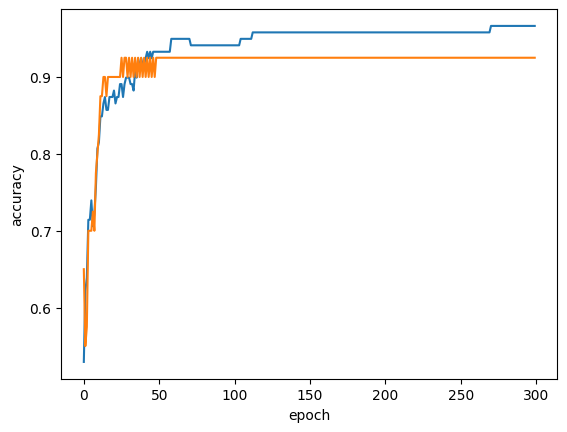

In [28]:
# 그 결과를 그래프로 확인하기

import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [29]:
# 훈련점수와 테스트 점수가 벌어지는 100번 에포크로 훈련 횟수 설정

sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [30]:
# 과제 1

In [31]:
# 1.1 데이터셋 가져오기

import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [35]:
# 1.2 테스트, 훈련 세트 분리
fish_input = fish[['Weight','Length','Diagonal','Height','Width']]
fish_target = fish['Species']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [33]:
# 1.3 표준 정규화하기

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [36]:
# 1.4 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [37]:
# 1.5 새 테이터셋 예측값 출력

test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

test_data_scaled = ss.transform(test_data)
predictions = lr.predict(test_data_scaled)
print(predictions)



['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
# 1.6 물고기 별 확률값 확인
import numpy as np
proba = lr.predict_proba(test_data_scaled)
print(np.round(proba, decimals=3))

[[0.451 0.049 0.008 0.006 0.384 0.    0.102]
 [0.    0.002 0.048 0.    0.009 0.941 0.   ]
 [0.    0.    0.287 0.713 0.    0.    0.   ]
 [0.    0.013 0.512 0.001 0.461 0.002 0.011]
 [0.368 0.094 0.    0.    0.009 0.    0.528]]


In [ ]:
# 과제 2

In [39]:
# 2.1 데이터셋 가져오기

import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [61]:
# 2.2, 2.3 SGDclassifier 모델 훈련하기
from sklearn.linear_model import SGDClassifier

# 데이터 분할 및 전처리는 앞선 변수(train_scaled, test_scaled 등)를 활용합니다.
sc1 = SGDClassifier(loss='hinge', max_iter=10, tol=None, random_state=42)
sc1.fit(train_scaled, train_target)

sc2 = SGDClassifier(loss='hinge', max_iter=300, tol=None, random_state=42)
sc2.fit(train_scaled, train_target)





SGDClassifier(max_iter=300, random_state=42, tol=None)

In [60]:
# 2.4 매 에포크마다 훈련 점수와 테스트 점수 기록
import numpy as np

sc = SGDClassifier(loss='hinge', random_state=42)
train_score = []
test_score = []

classes = np.unique(train_target)

# 300번의 에포크 동안 반복
for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

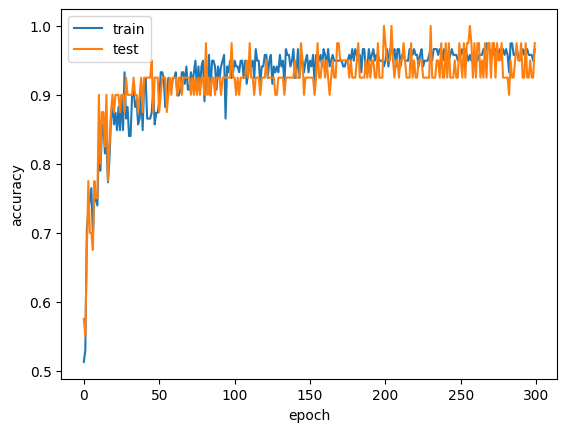

In [54]:
# 2.5 에포크를 x축 정확도를 y축으로 하는 matplotlib 그래프 그리기
import matplotlib.pyplot as plt

plt.plot(train_score, label='train')
plt.plot(test_score, label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
# 2.6 그래프 분석

# 에포크 수가 늘어도 큰 변화가 없어지는 지점인 50을 선택하면 될 것 같디


In [59]:
# 2.7 해당 에포크 수(50)로 모델 훈련 및 비교
sc_final = SGDClassifier(loss='hinge', max_iter=50, tol=None, random_state=42)
sc_final.fit(train_scaled, train_target)

print('--- [비교] 에포크 10 결과 ---')
print(f'Train Score: {sc1.score(train_scaled, train_target)}')
print(f'Test Score: {sc1.score(test_scaled, test_target)}')

print('\n--- [최종] 에포크 50 결과 ---')
print(f'Train Score: {sc_final.score(train_scaled, train_target)}')
print(f'Test Score: {sc_final.score(test_scaled, test_target)}')

#음.. 결과가 더 안좋네요

--- [비교] 에포크 10 결과 ---
Train Score: 0.9663865546218487
Test Score: 0.975

--- [최종] 에포크 50 결과 ---
Train Score: 0.9243697478991597
Test Score: 0.925
